# 03 - Model Benchmark (Maximum-Detail)

This notebook builds the full **model leaderboard** that downstream tuning (`04_*`, `optimize.py`) and explainability (`04_explainability_*`) consume.

It depends on:
- **Notebook 01 — EDA**: established the target rate (~26.5% positives), the high-risk segments (Month-to-month + Fiber Optic + Electronic Check), and the business cost model (revenue-at-risk).
- **Notebook 02 — Preprocessing diagnostics**: validated the `ColumnTransformer` produced by `src.preprocessing.build_preprocessor`. We re-use the same leakage-safe pipeline here.

## Modeling principles
1. **Same split everywhere**: stratified 70 / 15 / 15 (train / valid / test) with `random_state=42`, identical to `src/train.py`. Train builds the model, valid is for threshold/HP decisions, test is touched once for the final leaderboard.
2. **Pipelines, not transforms**: every model is wrapped in `Pipeline([preprocessor, model])` so the encoder/scaler/imputer are fit only on training folds.
3. **Class imbalance respected**: sklearn-friendly models receive `class_weight='balanced'`; XGBoost gets the equivalent `scale_pos_weight`.
4. **Multi-metric comparison**: ROC-AUC, PR-AUC, F1, recall, precision, log-loss, Brier score, and top-decile lift — no single metric dominates a churn use case.
5. **Robustness checks**: 5-fold CV variance, bootstrap CI on test AUC, and per-segment AUC (Contract, Internet, Tenure bucket).
6. **Threshold-aware**: the default 0.5 threshold is rarely optimal under imbalance; we tune for F1 and for expected business cost.

## Section map
1. Setup, splits, and quality contract
2. Model registry (6 algorithms)
3. 5-fold CV benchmark on training set (multi-metric + timing)
4. Fit-on-train, score on valid + test (full leaderboard)
5. Pretty leaderboard and rank heatmap
6. ROC / PR / Calibration overlays
7. Confusion matrix grid (default vs tuned threshold)
8. Threshold optimization (F1-max and cost-min)
9. Lift, cumulative gains, and top-decile capture
10. Class-conditional probability distributions
11. Per-segment performance audit (Contract / Internet / Tenure)
12. Bootstrap confidence intervals on test ROC-AUC
13. Champion selection and diagnostic dashboard
14. Persist champion artifacts
15. Findings and hand-off to Optuna

In [1]:
import sys
import time
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)

REPO_ROOT = Path('..').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.preprocessing import (
    TARGET_COLUMN,
    build_preprocessor,
    engineer_features,
    load_data,
    split_features_target,
)
from src.models import evaluate_predictions, get_model_registry

DATA_PATH = REPO_ROOT / 'data' / 'raw' / 'telco.csv'
RANDOM_STATE = 42

df_raw = load_data(str(DATA_PATH))
df_engineered = engineer_features(df_raw)
prepared = split_features_target(df_engineered)
X, y = prepared.X, prepared.y

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y,
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp,
)

split_summary = pd.DataFrame({
    'split': ['train', 'valid', 'test', 'total'],
    'rows': [len(X_train), len(X_valid), len(X_test), len(X)],
    'positives': [int(y_train.sum()), int(y_valid.sum()), int(y_test.sum()), int(y.sum())],
    'churn_rate': [y_train.mean(), y_valid.mean(), y_test.mean(), y.mean()],
})
display(split_summary)
assert abs(y_train.mean() - y_test.mean()) < 0.01
print('PASS: stratified 70/15/15 split with churn-rate parity.')

,split,rows,positives,churn_rate
0,train,4930,1308,0.2653
1,valid,1056,280,0.2652
2,test,1057,281,0.2658
3,total,7043,1869,0.2654


PASS: stratified 70/15/15 split with churn-rate parity.


## 1) Model Registry

We benchmark **six** algorithms covering the bias-variance and interpretability spectrum:

| Model | Family | Why it's here |
|---|---|---|
| `logistic_regression` | Linear | Baseline / interpretable / well-calibrated |
| `random_forest` | Bagged trees | Captures non-linearities without tuning, easy SHAP |
| `xgboost` | Gradient boosting | Industry standard for tabular churn |
| `lightgbm` | Gradient boosting | Fast leaf-wise growth, native categorical handling |
| `catboost` | Gradient boosting | Robust to default hyperparameters, ordered boosting |
| `hist_gradient_boosting` | Gradient boosting | sklearn's native HGBT, dependency-free fallback |

The first 4 also support class-weighting natively, which matches the EDA-driven imbalance strategy. XGBoost uses an equivalent `scale_pos_weight` that we set explicitly.

In [2]:
scale_pos_weight = float((y_train == 0).sum()) / float(max((y_train == 1).sum(), 1))
print(f'XGBoost scale_pos_weight = neg/pos = {scale_pos_weight:.4f}')

model_registry = get_model_registry(class_weight='balanced')
if 'xgboost' in model_registry:
    model_registry['xgboost'].set_params(scale_pos_weight=scale_pos_weight)

registry_summary = pd.DataFrame([
    {
        'model': name,
        'class': est.__class__.__name__,
        'imbalance_handling': (
            'class_weight=balanced' if name in {'logistic_regression', 'random_forest', 'lightgbm'}
            else (f'scale_pos_weight={scale_pos_weight:.2f}' if name == 'xgboost'
                  else 'auto-class-weights' if name == 'catboost'
                  else 'none (vanilla HGBT)')
        ),
    }
    for name, est in model_registry.items()
])
display(registry_summary)

XGBoost scale_pos_weight = neg/pos = 2.7691


,model,class,imbalance_handling
0,logistic_regression,LogisticRegression,class_weight=balanced
1,random_forest,RandomForestClassifier,class_weight=balanced
2,xgboost,XGBClassifier,scale_pos_weight=2.77
3,lightgbm,LGBMClassifier,class_weight=balanced
4,catboost,CatBoostClassifier,auto-class-weights
5,hist_gradient_boosting,HistGradientBoostingClassifier,none (vanilla HGBT)


## 2) 5-Fold CV Benchmark on the Training Set

Before we touch valid/test, we run **stratified 5-fold cross-validation on the training split** for every model, scoring four metrics simultaneously:
- `roc_auc` — discrimination
- `average_precision` (PR-AUC) — robust under imbalance
- `f1`
- `neg_log_loss` — calibration

This gives us mean ± std for each model and reveals which models are stable vs noisy. We also record fit time as a runtime budget signal for tuning.

In [3]:
cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
    'f1': 'f1',
    'neg_log_loss': 'neg_log_loss',
}

cv_records = []
cv_score_distributions = {metric: {} for metric in scoring}

for name, estimator in model_registry.items():
    pipeline = Pipeline([
        ('preprocessor', build_preprocessor(X_train)),
        ('model', estimator),
    ])
    t0 = time.time()
    cv_result = cross_validate(
        pipeline, X_train, y_train,
        cv=cv_splitter, scoring=scoring,
        n_jobs=1, return_train_score=False,
    )
    elapsed = time.time() - t0
    record = {'model': name, 'fit_seconds_total': elapsed}
    for metric in scoring:
        scores = cv_result[f'test_{metric}']
        cv_score_distributions[metric][name] = scores
        record[f'{metric}_mean'] = scores.mean()
        record[f'{metric}_std'] = scores.std()
    cv_records.append(record)
    print(f'  {name:<24s} done in {elapsed:6.1f}s | ROC-AUC={record["roc_auc_mean"]:.4f} ± {record["roc_auc_std"]:.4f}')

cv_df = pd.DataFrame(cv_records).sort_values('roc_auc_mean', ascending=False)
display(cv_df)

  logistic_regression      done in    0.3s | ROC-AUC=0.8472 ± 0.0101


  random_forest            done in    3.8s | ROC-AUC=0.8324 ± 0.0098


  xgboost                  done in    2.0s | ROC-AUC=0.8427 ± 0.0120


  lightgbm                 done in    3.4s | ROC-AUC=0.8364 ± 0.0108


  catboost                 done in    7.9s | ROC-AUC=0.8440 ± 0.0124


  hist_gradient_boosting   done in    1.4s | ROC-AUC=0.8362 ± 0.0125


,model,fit_seconds_total,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,f1_mean,f1_std,neg_log_loss_mean,neg_log_loss_std
0,logistic_regression,0.3420,0.8472,0.0101,0.6693,0.0214,0.6329,0.0234,-0.4867,0.0166
4,catboost,7.9419,0.8440,0.0124,0.6614,0.0201,0.5881,0.0204,-0.4192,0.0146
2,xgboost,1.9734,0.8427,0.0120,0.6649,0.0190,0.6270,0.0228,-0.4654,0.0179
3,lightgbm,3.3622,0.8364,0.0108,0.6521,0.0175,0.6211,0.0169,-0.4767,0.0182
5,hist_gradient_boosting,1.4108,0.8362,0.0125,0.6473,0.0178,0.5716,0.0193,-0.4390,0.0185
1,random_forest,3.8457,0.8324,0.0098,0.6402,0.0190,0.5518,0.0178,-0.4417,0.0180


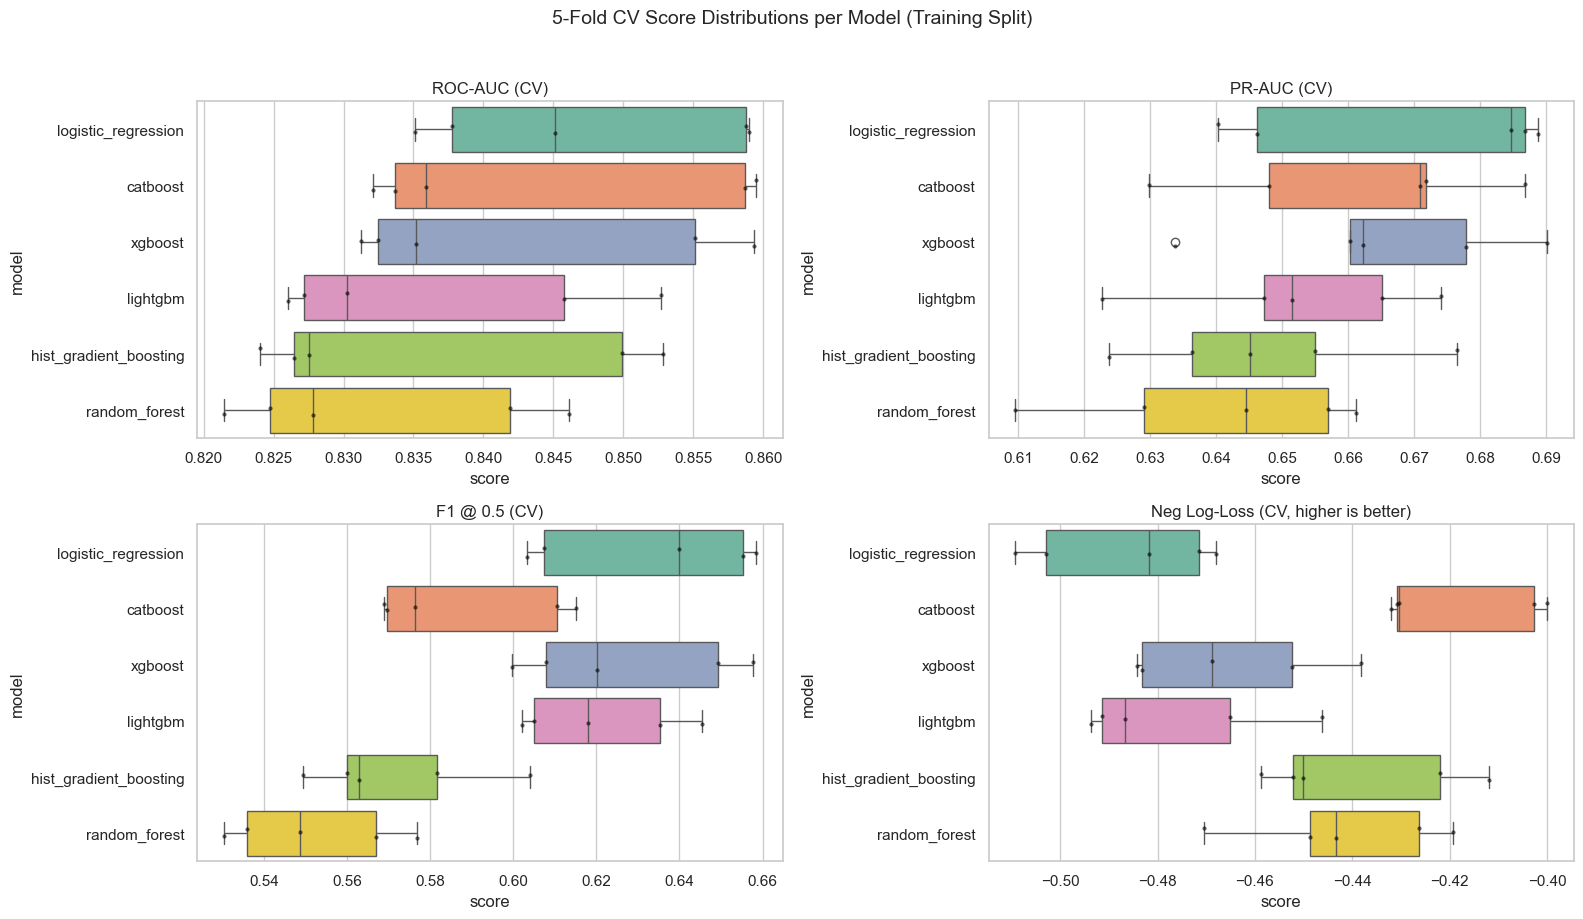

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
metric_titles = {
    'roc_auc': 'ROC-AUC (CV)',
    'pr_auc': 'PR-AUC (CV)',
    'f1': 'F1 @ 0.5 (CV)',
    'neg_log_loss': 'Neg Log-Loss (CV, higher is better)',
}
for ax, (metric, title) in zip(axes.flatten(), metric_titles.items()):
    long_df = pd.concat([
        pd.DataFrame({'model': model, 'score': scores})
        for model, scores in cv_score_distributions[metric].items()
    ], ignore_index=True)
    sns.boxplot(data=long_df, x='score', y='model', ax=ax,
                order=cv_df['model'].tolist(), palette='Set2')
    sns.stripplot(data=long_df, x='score', y='model', ax=ax,
                  order=cv_df['model'].tolist(), color='black', size=3, alpha=0.6)
    ax.set_title(title)
plt.suptitle('5-Fold CV Score Distributions per Model (Training Split)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 3) Fit on Train, Score on Validation + Test

We refit each pipeline on the **full training split**, then store predictions for valid and test. We compute the standard 7-metric battery (`evaluate_predictions` from `src.models`) plus **PR-AUC** and a business **top-decile lift** that the EDA section flagged as the main retention KPI.

In [5]:
def top_decile_lift(y_true: np.ndarray, y_prob: np.ndarray, top_frac: float = 0.10) -> float:
    """Lift = capture rate in top X% of scored customers / base churn rate."""
    n = len(y_true)
    cutoff = max(int(np.ceil(n * top_frac)), 1)
    order = np.argsort(-y_prob)
    captured_rate = float(np.asarray(y_true)[order][:cutoff].mean())
    base_rate = float(np.asarray(y_true).mean())
    return captured_rate / max(base_rate, 1e-9)


fitted_pipelines: dict[str, Pipeline] = {}
prob_valid: dict[str, np.ndarray] = {}
prob_test: dict[str, np.ndarray] = {}
leaderboard_rows = []

for name, estimator in model_registry.items():
    pipeline = Pipeline([
        ('preprocessor', build_preprocessor(X_train)),
        ('model', estimator),
    ])
    t0 = time.time()
    pipeline.fit(X_train, y_train)
    fit_time = time.time() - t0

    p_valid = pipeline.predict_proba(X_valid)[:, 1]
    p_test = pipeline.predict_proba(X_test)[:, 1]
    fitted_pipelines[name] = pipeline
    prob_valid[name] = p_valid
    prob_test[name] = p_test

    valid_metrics = evaluate_predictions(y_valid, p_valid, threshold=0.5)
    test_metrics = evaluate_predictions(y_test, p_test, threshold=0.5)
    leaderboard_rows.append({
        'model': name,
        'fit_seconds': fit_time,
        **{f'valid_{k}': v for k, v in valid_metrics.items()},
        'valid_pr_auc': average_precision_score(y_valid, p_valid),
        **{f'test_{k}': v for k, v in test_metrics.items()},
        'test_pr_auc': average_precision_score(y_test, p_test),
        'test_top_decile_lift': top_decile_lift(y_test.values, p_test, top_frac=0.10),
    })
    print(f'  {name:<24s} fit in {fit_time:5.1f}s | '
          f'test ROC-AUC={test_metrics["roc_auc"]:.4f} | '
          f'PR-AUC={leaderboard_rows[-1]["test_pr_auc"]:.4f} | '
          f'lift@10%={leaderboard_rows[-1]["test_top_decile_lift"]:.2f}x')

leaderboard = pd.DataFrame(leaderboard_rows).sort_values('test_roc_auc', ascending=False)

  logistic_regression      fit in   0.0s | test ROC-AUC=0.8477 | PR-AUC=0.6832 | lift@10%=3.02x


  random_forest            fit in   0.7s | test ROC-AUC=0.8264 | PR-AUC=0.6401 | lift@10%=2.84x


  xgboost                  fit in   0.4s | test ROC-AUC=0.8343 | PR-AUC=0.6633 | lift@10%=2.98x


  lightgbm                 fit in   0.3s | test ROC-AUC=0.8261 | PR-AUC=0.6449 | lift@10%=2.95x


  catboost                 fit in   1.6s | test ROC-AUC=0.8372 | PR-AUC=0.6627 | lift@10%=2.91x


  hist_gradient_boosting   fit in   0.2s | test ROC-AUC=0.8320 | PR-AUC=0.6446 | lift@10%=2.98x


## 4) Pretty Leaderboard and Rank Heatmap

We display two views:
1. The full leaderboard sorted by test ROC-AUC (multi-metric).
2. A heatmap of **per-metric rank** so we can see whether one model dominates across metrics or whether trade-offs emerge (e.g., top ROC-AUC but worst calibration).

,model,fit_seconds,test_roc_auc,test_pr_auc,test_f1,test_recall,test_precision,test_accuracy,test_top_decile_lift,test_log_loss,test_brier_score
0,logistic_regression,0.0487,0.8477,0.6832,0.6214,0.7651,0.5231,0.7521,3.0163,0.4725,0.1594
4,catboost,1.5639,0.8372,0.6627,0.5608,0.4840,0.6667,0.7985,2.9099,0.4242,0.1377
2,xgboost,0.3616,0.8343,0.6633,0.6186,0.7331,0.5351,0.7597,2.9809,0.4713,0.1564
5,hist_gradient_boosting,0.2401,0.8320,0.6446,0.5443,0.4698,0.6471,0.7909,2.9809,0.4438,0.1419
1,random_forest,0.7251,0.8264,0.6401,0.5325,0.4520,0.6480,0.7890,2.8389,0.4395,0.1424
3,lightgbm,0.3349,0.8261,0.6449,0.6095,0.6833,0.5501,0.7673,2.9454,0.4853,0.1570


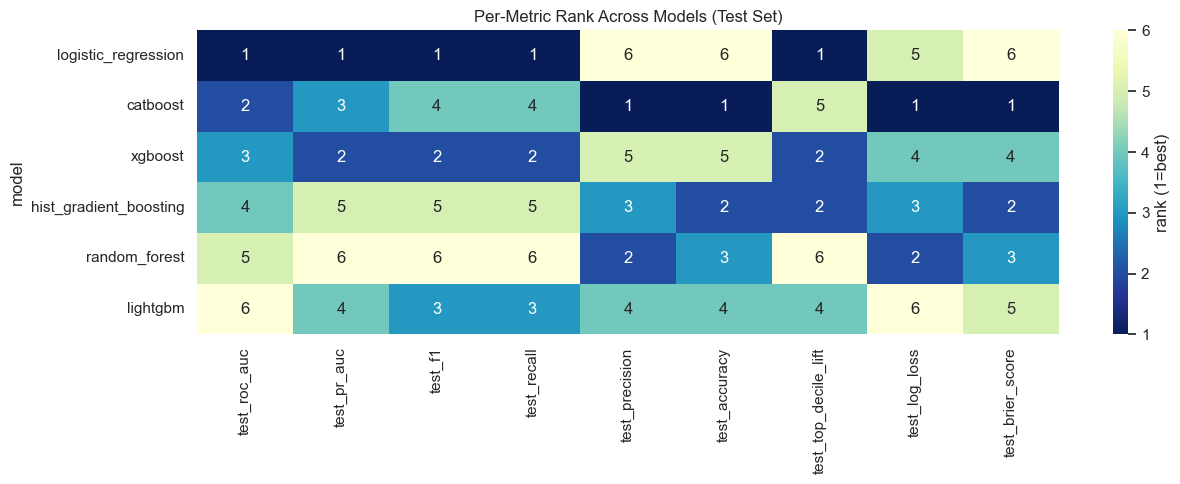

In [6]:
test_metric_cols = [
    'test_roc_auc', 'test_pr_auc', 'test_f1', 'test_recall',
    'test_precision', 'test_accuracy', 'test_top_decile_lift',
    'test_log_loss', 'test_brier_score',
]
display(leaderboard[['model', 'fit_seconds'] + test_metric_cols].round(4))

higher_is_better = {
    'test_roc_auc': True, 'test_pr_auc': True, 'test_f1': True,
    'test_recall': True, 'test_precision': True, 'test_accuracy': True,
    'test_top_decile_lift': True, 'test_log_loss': False, 'test_brier_score': False,
}
rank_df = pd.DataFrame({'model': leaderboard['model'].values})
for col, hib in higher_is_better.items():
    ranks = leaderboard[col].rank(ascending=not hib, method='min').astype(int)
    rank_df[col] = ranks.values
rank_df = rank_df.set_index('model')

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(rank_df, annot=True, cmap='YlGnBu_r', cbar_kws={'label': 'rank (1=best)'}, fmt='d', ax=ax)
ax.set_title('Per-Metric Rank Across Models (Test Set)')
plt.tight_layout()
plt.show()

## 5) ROC, Precision-Recall, and Calibration Overlays

Three diagnostic curves on the **test set** so we can visually compare:
- **ROC curve** — discrimination at every operating point.
- **Precision-Recall curve** — preferred view under class imbalance.
- **Calibration curve** — how trustworthy the predicted probabilities are (does P(churn)=0.7 actually mean ~70% churn rate?).

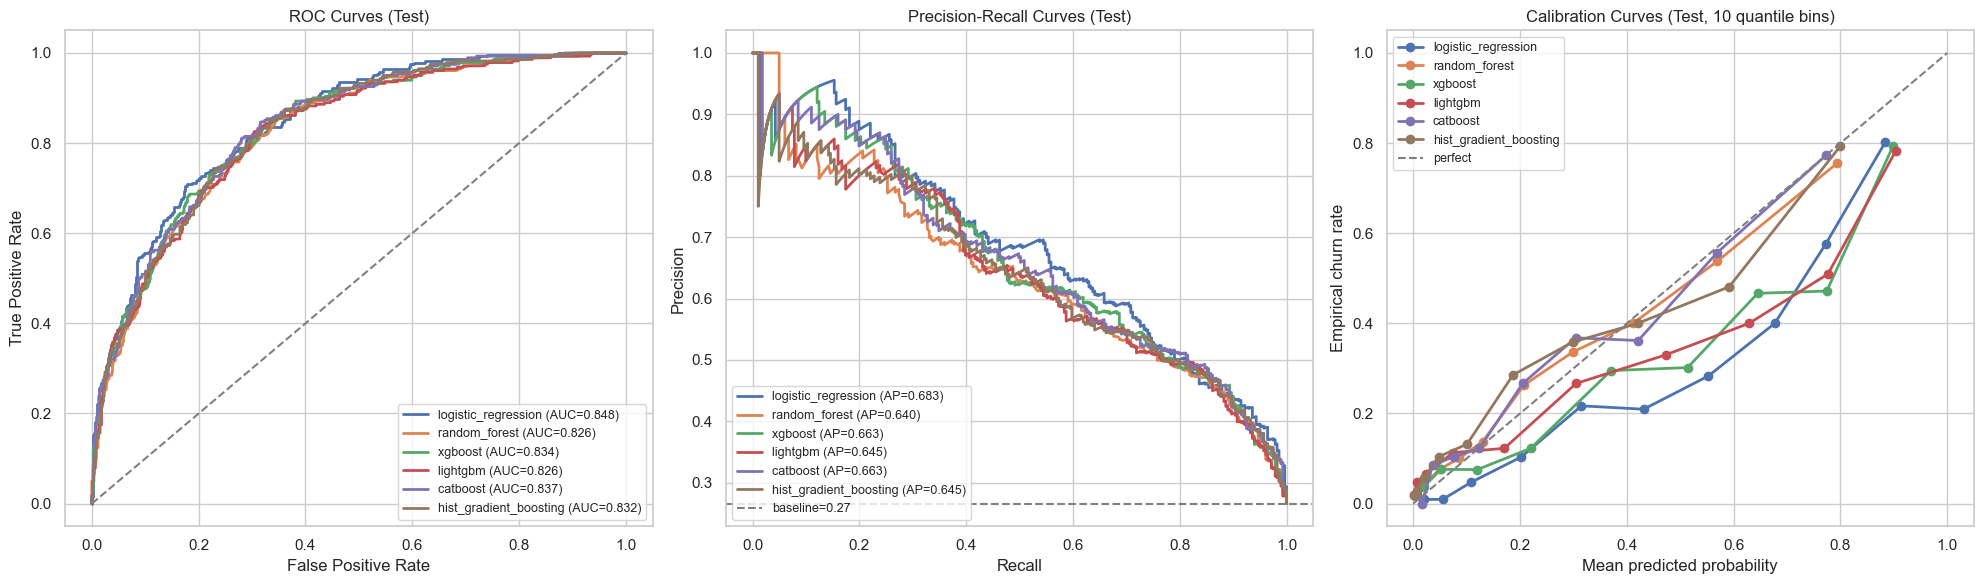

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for name, p_test in prob_test.items():
    fpr, tpr, _ = roc_curve(y_test, p_test)
    auc = roc_auc_score(y_test, p_test)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set_title('ROC Curves (Test)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right', fontsize=9)

for name, p_test in prob_test.items():
    prec, rec, _ = precision_recall_curve(y_test, p_test)
    pr_auc = average_precision_score(y_test, p_test)
    axes[1].plot(rec, prec, label=f'{name} (AP={pr_auc:.3f})', linewidth=2)
axes[1].axhline(y_test.mean(), linestyle='--', color='gray', label=f'baseline={y_test.mean():.2f}')
axes[1].set_title('Precision-Recall Curves (Test)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left', fontsize=9)

for name, p_test in prob_test.items():
    prob_true, prob_pred = calibration_curve(y_test, p_test, n_bins=10, strategy='quantile')
    axes[2].plot(prob_pred, prob_true, marker='o', label=name, linewidth=2)
axes[2].plot([0, 1], [0, 1], '--', color='gray', label='perfect')
axes[2].set_title('Calibration Curves (Test, 10 quantile bins)')
axes[2].set_xlabel('Mean predicted probability')
axes[2].set_ylabel('Empirical churn rate')
axes[2].legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

## 6) Threshold Optimization (F1-Max and Cost-Min)

A 0.5 threshold is rarely correct under class imbalance with asymmetric costs. We sweep thresholds for each model on the **validation set** and pick:
- **F1-max** threshold — best balance of precision/recall.
- **Cost-min** threshold — minimum expected business loss given a cost matrix derived from the EDA section.

### Cost model
- **False Negative (missed churner)**: lose ~12 months of MRR ≈ **$800** average.
- **False Positive (unnecessary retention offer)**: campaign cost ≈ **$50**.

So the cost ratio FN:FP ≈ 16:1, which strongly biases the optimal threshold below 0.5.

In [8]:
FN_COST = 800.0
FP_COST = 50.0

def best_threshold(y_true, y_prob, mode='f1', fn_cost=FN_COST, fp_cost=FP_COST):
    thresholds = np.linspace(0.05, 0.95, 91)
    best_t, best_score = 0.5, None
    history = []
    for t in thresholds:
        y_hat = (y_prob >= t).astype(int)
        if mode == 'f1':
            score = f1_score(y_true, y_hat, zero_division=0)
            history.append((t, score))
            if best_score is None or score > best_score:
                best_score, best_t = score, t
        elif mode == 'cost':
            fn = ((y_hat == 0) & (y_true == 1)).sum()
            fp = ((y_hat == 1) & (y_true == 0)).sum()
            cost = fn * fn_cost + fp * fp_cost
            history.append((t, cost))
            if best_score is None or cost < best_score:
                best_score, best_t = cost, t
    return best_t, best_score, history

threshold_rows = []
for name in fitted_pipelines:
    p_valid = prob_valid[name]
    p_test = prob_test[name]

    f1_t, f1_score_v, _ = best_threshold(y_valid.values, p_valid, mode='f1')
    cost_t, cost_v, _ = best_threshold(y_valid.values, p_valid, mode='cost')

    metrics_default = evaluate_predictions(y_test, p_test, threshold=0.5)
    metrics_f1opt = evaluate_predictions(y_test, p_test, threshold=f1_t)
    metrics_costopt = evaluate_predictions(y_test, p_test, threshold=cost_t)

    yh_default = (p_test >= 0.5).astype(int)
    yh_costopt = (p_test >= cost_t).astype(int)
    cost_default = ((yh_default == 0) & (y_test == 1)).sum() * FN_COST + \
                   ((yh_default == 1) & (y_test == 0)).sum() * FP_COST
    cost_at_costopt = ((yh_costopt == 0) & (y_test == 1)).sum() * FN_COST + \
                      ((yh_costopt == 1) & (y_test == 0)).sum() * FP_COST

    threshold_rows.append({
        'model': name,
        'f1_threshold (valid)': f1_t,
        'cost_threshold (valid)': cost_t,
        'F1@0.5': metrics_default['f1'],
        'F1@F1opt': metrics_f1opt['f1'],
        'F1@CostOpt': metrics_costopt['f1'],
        'recall@CostOpt': metrics_costopt['recall'],
        'precision@CostOpt': metrics_costopt['precision'],
        'test_cost@0.5 ($)': cost_default,
        'test_cost@CostOpt ($)': cost_at_costopt,
        'savings ($)': cost_default - cost_at_costopt,
    })

threshold_df = pd.DataFrame(threshold_rows).sort_values('test_cost@CostOpt ($)')
display(threshold_df)

,model,f1_threshold (valid),cost_threshold (valid),F1@0.5,F1@F1opt,F1@CostOpt,recall@CostOpt,precision@CostOpt,test_cost@0.5 ($),test_cost@CostOpt ($),savings ($)
0,logistic_regression,0.5500,0.1200,0.6214,0.6329,0.5237,0.9822,0.3571,62600.0000,28850.0000,33750.0000
2,xgboost,0.5600,0.0600,0.6186,0.6266,0.5162,0.9644,0.3524,68950.0000,32900.0000,36050.0000
4,catboost,0.3000,0.0700,0.5608,0.6116,0.5438,0.9502,0.3809,119400.0000,32900.0000,86500.0000
1,random_forest,0.2800,0.0600,0.5325,0.6030,0.5143,0.9573,0.3516,126650.0000,34400.0000,92250.0000
3,lightgbm,0.4100,0.1200,0.6095,0.6081,0.5623,0.9075,0.4073,79050.0000,39350.0000,39700.0000
5,hist_gradient_boosting,0.2100,0.1000,0.5443,0.6139,0.5820,0.8968,0.4308,122800.0000,39850.0000,82950.0000


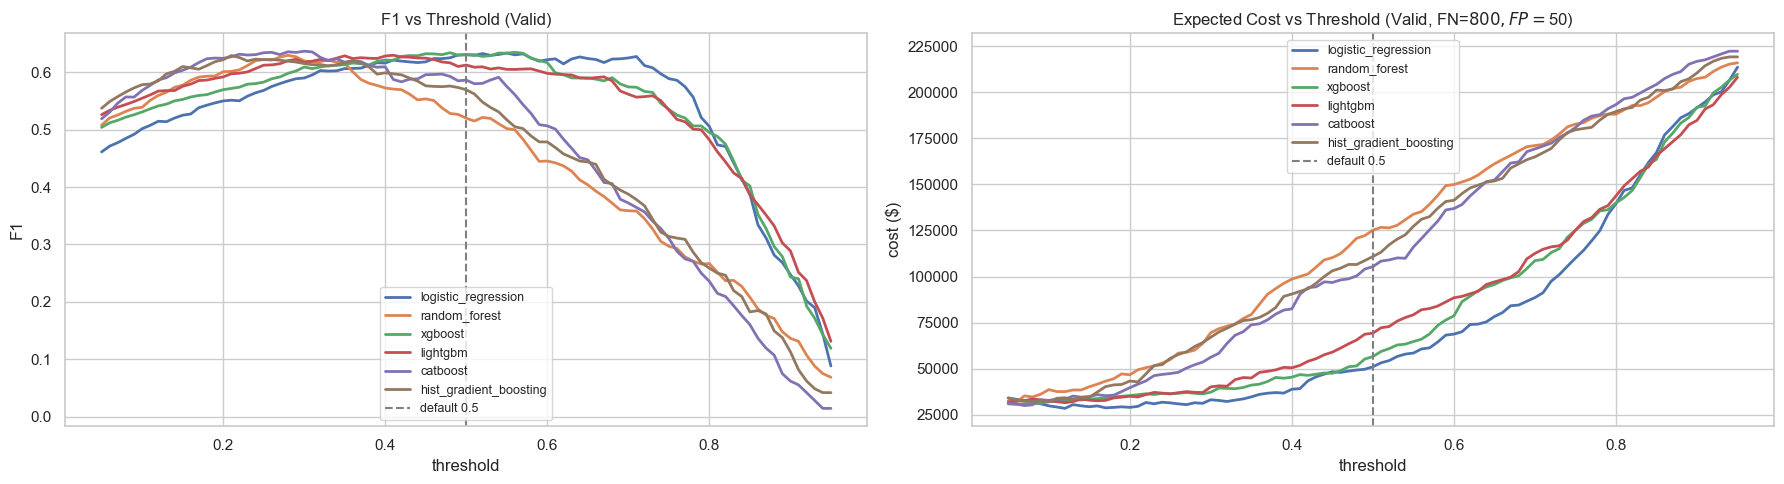

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
threshold_grid = np.linspace(0.05, 0.95, 91)

for name, p_valid in prob_valid.items():
    f1s = [f1_score(y_valid, (p_valid >= t).astype(int), zero_division=0) for t in threshold_grid]
    costs = []
    for t in threshold_grid:
        y_hat = (p_valid >= t).astype(int)
        fn = ((y_hat == 0) & (y_valid == 1)).sum()
        fp = ((y_hat == 1) & (y_valid == 0)).sum()
        costs.append(fn * FN_COST + fp * FP_COST)
    axes[0].plot(threshold_grid, f1s, label=name, linewidth=2)
    axes[1].plot(threshold_grid, costs, label=name, linewidth=2)

axes[0].axvline(0.5, color='gray', linestyle='--', label='default 0.5')
axes[0].set_title('F1 vs Threshold (Valid)')
axes[0].set_xlabel('threshold'); axes[0].set_ylabel('F1')
axes[0].legend(fontsize=9, loc='lower center')

axes[1].axvline(0.5, color='gray', linestyle='--', label='default 0.5')
axes[1].set_title(f'Expected Cost vs Threshold (Valid, FN=${FN_COST:.0f}, FP=${FP_COST:.0f})')
axes[1].set_xlabel('threshold'); axes[1].set_ylabel('cost ($)')
axes[1].legend(fontsize=9, loc='upper center')

plt.tight_layout()
plt.show()

## 7) Confusion Matrix Grid (Default vs Cost-Optimal Threshold)

Same models, two thresholds. The cost-optimal column is what a retention team would actually deploy.

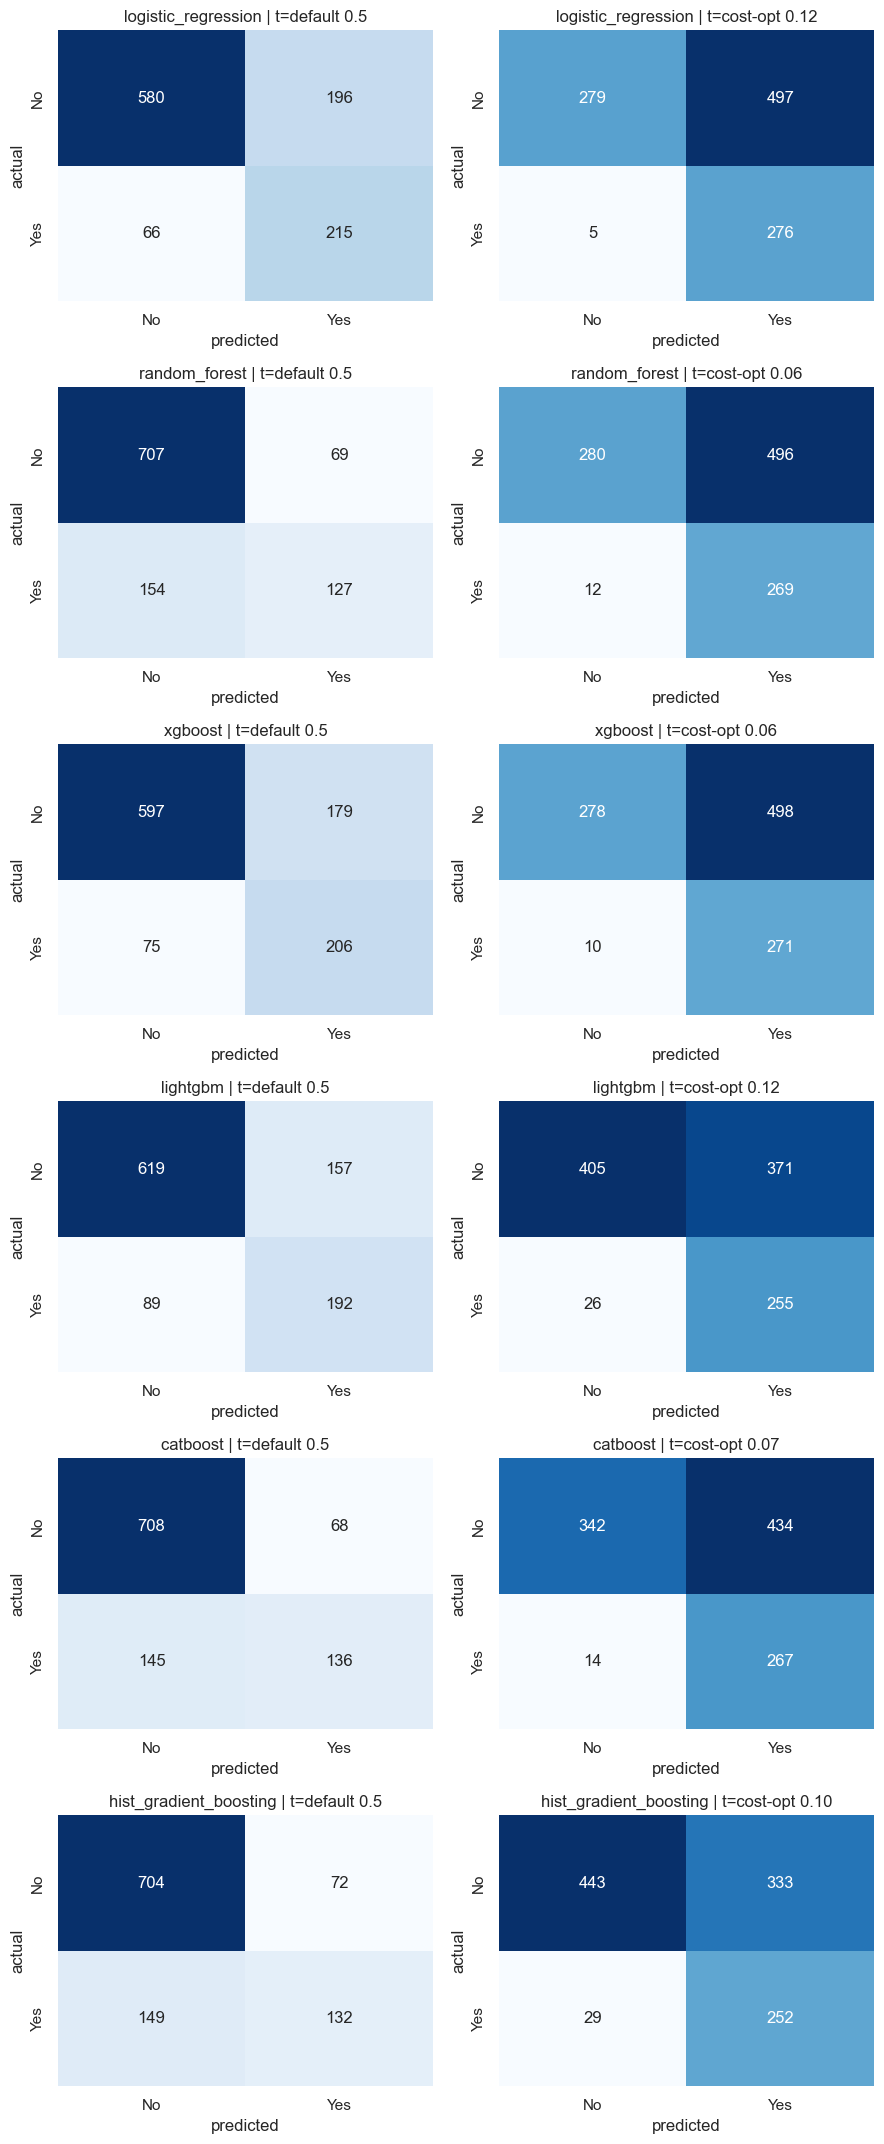

In [10]:
from sklearn.metrics import confusion_matrix

cost_thresholds = dict(zip(threshold_df['model'], threshold_df['cost_threshold (valid)']))
n_models = len(prob_test)
fig, axes = plt.subplots(n_models, 2, figsize=(9, 3.6 * n_models))
if n_models == 1:
    axes = np.array([axes])

for i, (name, p_test) in enumerate(prob_test.items()):
    for j, (label, t) in enumerate([('default 0.5', 0.5), (f'cost-opt {cost_thresholds[name]:.2f}', cost_thresholds[name])]):
        y_hat = (p_test >= t).astype(int)
        cm = confusion_matrix(y_test, y_hat)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i, j],
                    xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
        axes[i, j].set_title(f'{name} | t={label}')
        axes[i, j].set_xlabel('predicted')
        axes[i, j].set_ylabel('actual')

plt.tight_layout()
plt.show()

## 8) Lift, Cumulative Gains, and Top-Decile Capture

Marketing-friendly view: if we contact only the **top X%** of customers ranked by predicted risk, what fraction of all churners do we capture and how concentrated is the score?

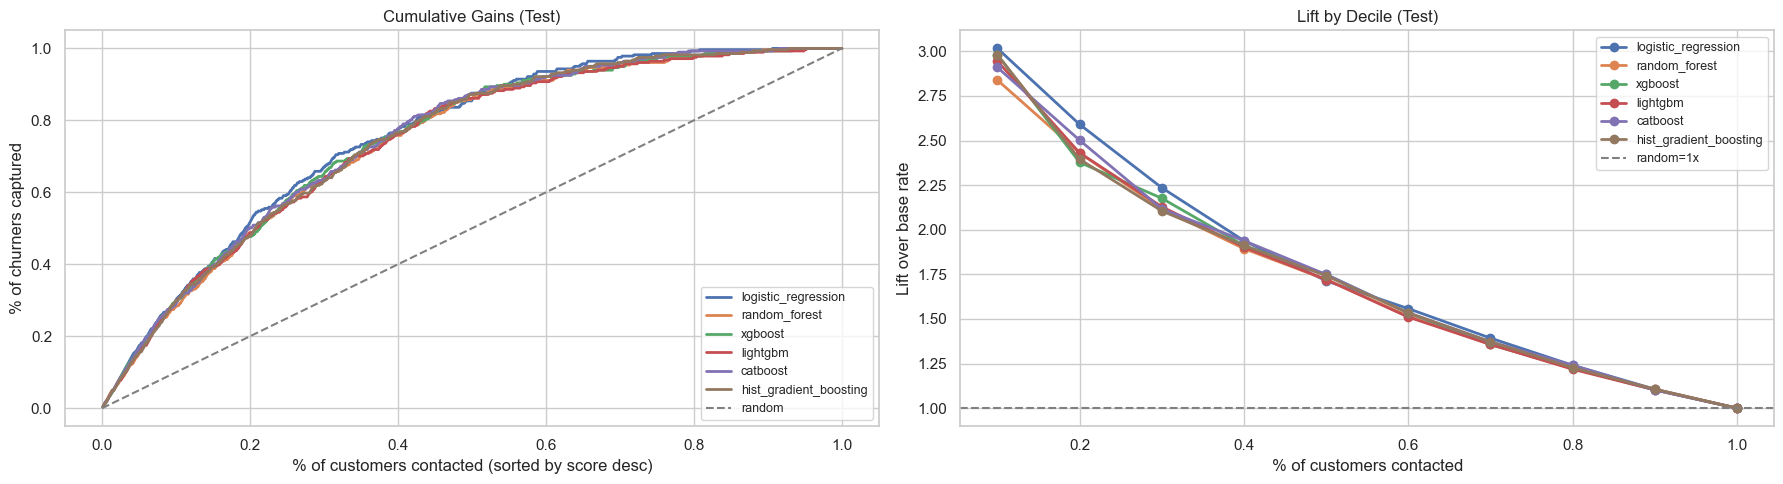

,model,lift@10%,lift@20%,lift@30%,lift@40%,lift@50%,lift@60%,lift@70%,lift@80%,lift@90%,lift@100%
0,logistic_regression,3.0200,2.5900,2.2400,1.9400,1.7100,1.5600,1.3900,1.2400,1.1100,1.0000
1,random_forest,2.8400,2.4300,2.1200,1.8900,1.7200,1.5200,1.3600,1.2200,1.1100,1.0000
2,xgboost,2.9800,2.3800,2.1800,1.9100,1.7500,1.5300,1.3600,1.2200,1.1000,1.0000
3,lightgbm,2.9500,2.4300,2.1300,1.9000,1.7200,1.5100,1.3600,1.2200,1.1000,1.0000
4,catboost,2.9100,2.5000,2.1200,1.9400,1.7500,1.5300,1.3700,1.2400,1.1000,1.0000
5,hist_gradient_boosting,2.9800,2.4000,2.1100,1.9100,1.7400,1.5300,1.3700,1.2300,1.1100,1.0000


In [11]:
def cumulative_gain_curve(y_true, y_prob, n_bins: int = 100):
    n = len(y_true)
    order = np.argsort(-y_prob)
    sorted_y = np.asarray(y_true)[order]
    cum_pos = np.cumsum(sorted_y)
    total_pos = sorted_y.sum()
    contacted_pct = np.arange(1, n + 1) / n
    captured_pct = cum_pos / max(total_pos, 1)
    return contacted_pct, captured_pct

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
deciles = np.arange(0.1, 1.01, 0.1)
decile_lift_rows = []

for name, p_test in prob_test.items():
    contacted, captured = cumulative_gain_curve(y_test.values, p_test)
    axes[0].plot(contacted, captured, label=name, linewidth=2)
    base_rate = y_test.mean()
    lift_curve = []
    for d in deciles:
        cutoff = max(int(np.ceil(len(y_test) * d)), 1)
        order = np.argsort(-p_test)
        rate = float(np.asarray(y_test)[order][:cutoff].mean())
        lift_curve.append(rate / max(base_rate, 1e-9))
    axes[1].plot(deciles, lift_curve, marker='o', label=name, linewidth=2)
    decile_lift_rows.append({'model': name, **{f'lift@{int(d*100)}%': lc for d, lc in zip(deciles, lift_curve)}})

axes[0].plot([0, 1], [0, 1], '--', color='gray', label='random')
axes[0].set_title('Cumulative Gains (Test)')
axes[0].set_xlabel('% of customers contacted (sorted by score desc)')
axes[0].set_ylabel('% of churners captured')
axes[0].legend(fontsize=9, loc='lower right')

axes[1].axhline(1.0, color='gray', linestyle='--', label='random=1x')
axes[1].set_title('Lift by Decile (Test)')
axes[1].set_xlabel('% of customers contacted')
axes[1].set_ylabel('Lift over base rate')
axes[1].legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

display(pd.DataFrame(decile_lift_rows).round(2))

## 9) Class-Conditional Probability Distributions

For each model we plot the distribution of predicted P(churn) split by the **actual label**. A well-discriminating model produces clearly separated peaks.

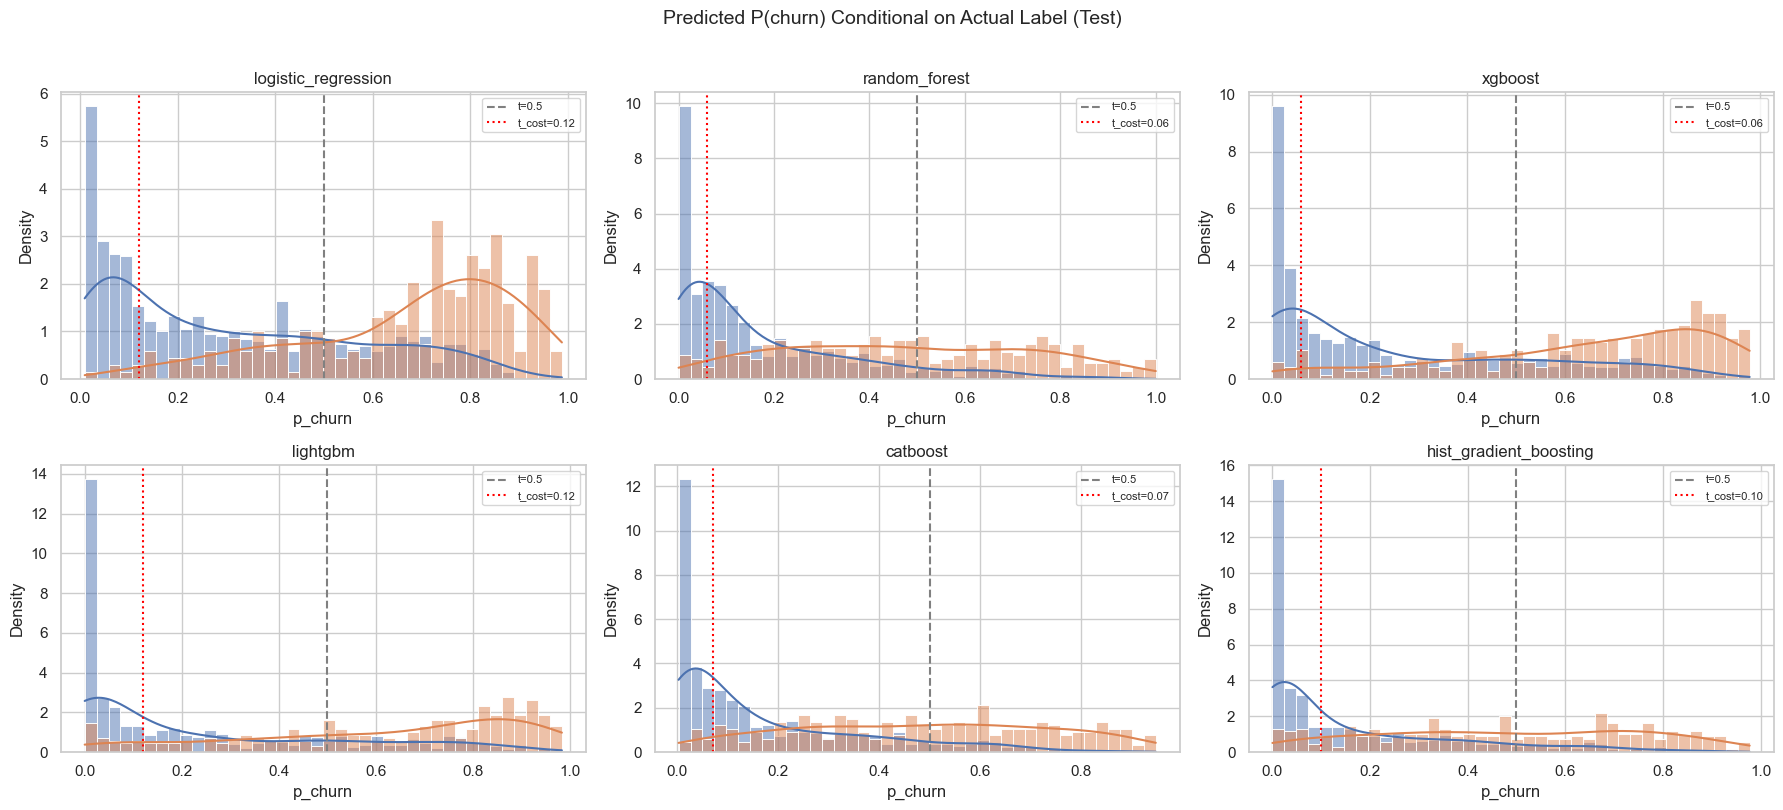

In [12]:
n_models = len(prob_test)
ncols = 3
nrows = int(np.ceil(n_models / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
axes = axes.flatten()

for ax, (name, p_test) in zip(axes, prob_test.items()):
    df_kde = pd.DataFrame({'p_churn': p_test, 'actual': y_test.map({0: 'No churn', 1: 'Churn'}).values})
    sns.histplot(data=df_kde, x='p_churn', hue='actual', bins=40, kde=True,
                 stat='density', common_norm=False, ax=ax, palette={'No churn': '#4c72b0', 'Churn': '#dd8452'})
    ax.axvline(0.5, color='gray', linestyle='--', label='t=0.5')
    if name in cost_thresholds:
        ax.axvline(cost_thresholds[name], color='red', linestyle=':', label=f't_cost={cost_thresholds[name]:.2f}')
    ax.set_title(f'{name}')
    ax.legend(fontsize=8)

for ax in axes[n_models:]:
    ax.axis('off')

plt.suptitle('Predicted P(churn) Conditional on Actual Label (Test)', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## 10) Per-Segment Performance Audit

Robust models perform consistently across business segments. We measure test ROC-AUC for each model on three EDA-flagged dimensions:
- **Contract**: month-to-month vs annual
- **InternetService**: Fiber Optic (high-churn) vs DSL vs No internet
- **Tenure bucket**: 0–6 months / 7–24 / 25+ months

A model that wins overall but collapses on Fiber Optic + Month-to-month is **not** a deployable champion.

model                                          catboost  \
dimension       segment        n   churn_rate             
Contract        Month-to-month 572 0.4248        0.7497   
                One year       229 0.1441        0.7028   
                Two year       256 0.0195        0.7960   
InternetService DSL            377 0.1963        0.8322   
                Fiber optic    441 0.4150        0.7783   
                No             239 0.1004        0.8275   
Tenure          0-6m           229 0.5415        0.7964   
                25+m           578 0.1367        0.8320   
                7-24m          250 0.3120        0.7336   

model                                          hist_gradient_boosting  \
dimension       segment        n   churn_rate                           
Contract        Month-to-month 572 0.4248                      0.7403   
                One year       229 0.1441                      0.7304   
                Two year       256 0.0195                      0.7745   
InternetService DSL            377 0.1963                      0.8457   
                Fiber optic    441 0.4150                      0.7637   
                No             239 0.1004                      0.7724   
Tenure          0-6m           229 0.5415                      0.7810   
                25+m           578 0.1367                      0.8347   
                7-24m          250 0.3120                      0.7218   

model                                          lightgbm  logistic_regression  \
dimension       segment        n   churn_rate                                  
Contract        Month-to-month 572 0.4248        0.7409               0.7642   
                One year       229 0.1441        0.6985               0.7404   
                Two year       256 0.0195        0.6765               0.8096   
InternetService DSL            377 0.1963        0.8379               0.8336   
                Fiber optic    441 0.4150        0.7612               0.8000   
                No             239 0.1004        0.7491               0.8393   
Tenure          0-6m           229 0.5415        0.7892               0.7922   
                25+m           578 0.1367        0.8154               0.8454   
                7-24m          250 0.3120        0.7174               0.7549   

model                                          random_forest  xgboost  
dimension       segment        n   churn_rate                          
Contract        Month-to-month 572 0.4248             0.7366   0.7504  
                One year       229 0.1441             0.6801   0.6985  
                Two year       256 0.0195             0.7267   0.7689  
InternetService DSL            377 0.1963             0.8134   0.8398  
                Fiber optic    441 0.4150             0.7692   0.7767  
                No             239 0.1004             0.7940   0.7704  
Tenure          0-6m           229 0.5415             0.7680   0.7896  
                25+m           578 0.1367             0.8207   0.8316  
                7-24m          250 0.3120             0.7283   0.7338

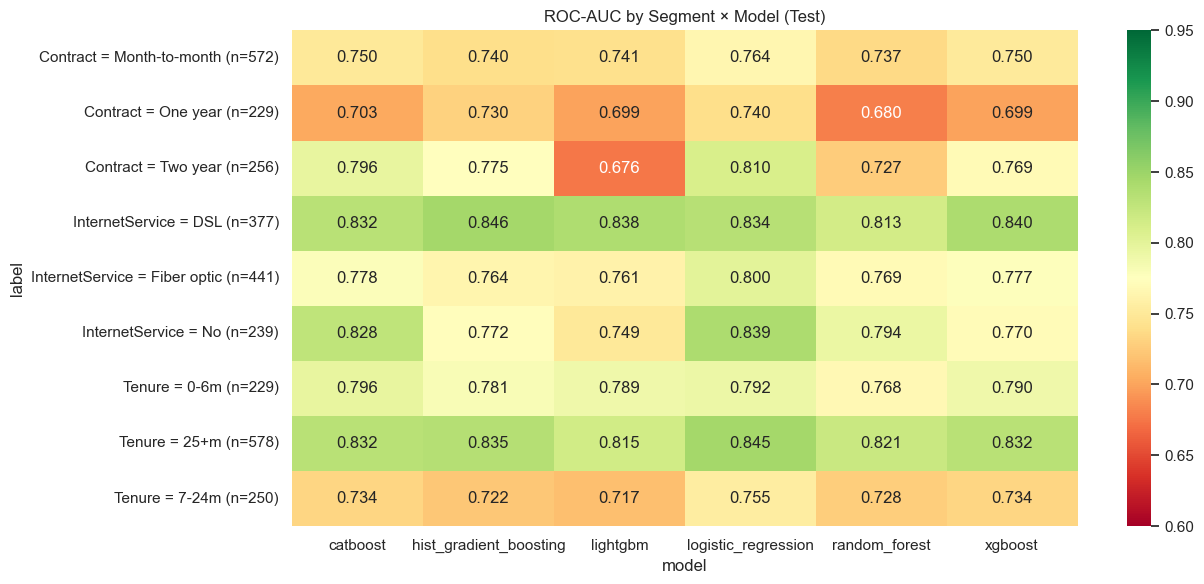

In [13]:
tenure_bucket = pd.cut(
    X_test['tenure'],
    bins=[-0.1, 6, 24, 72],
    labels=['0-6m', '7-24m', '25+m'],
)
segments = {
    'Contract': X_test['Contract'].astype(str),
    'InternetService': X_test['InternetService'].astype(str),
    'Tenure': tenure_bucket.astype(str),
}

segment_rows = []
for dim_name, segment_series in segments.items():
    for seg_value in segment_series.unique():
        mask = (segment_series == seg_value).values
        if mask.sum() < 30 or y_test[mask].nunique() < 2:
            continue
        for name, p_test in prob_test.items():
            try:
                auc = roc_auc_score(y_test[mask], p_test[mask])
            except ValueError:
                auc = np.nan
            segment_rows.append({
                'dimension': dim_name,
                'segment': seg_value,
                'n': int(mask.sum()),
                'churn_rate': float(y_test[mask].mean()),
                'model': name,
                'roc_auc': auc,
            })

segment_df = pd.DataFrame(segment_rows)
segment_pivot = segment_df.pivot_table(
    index=['dimension', 'segment', 'n', 'churn_rate'],
    columns='model', values='roc_auc',
).round(4)
display(segment_pivot)

fig, ax = plt.subplots(figsize=(13, 6))
plot_pivot = segment_df.assign(
    label=lambda d: d['dimension'] + ' = ' + d['segment'] + ' (n=' + d['n'].astype(str) + ')'
).pivot_table(index='label', columns='model', values='roc_auc')
sns.heatmap(plot_pivot, annot=True, cmap='RdYlGn', vmin=0.6, vmax=0.95, fmt='.3f', ax=ax)
ax.set_title('ROC-AUC by Segment × Model (Test)')
plt.tight_layout()
plt.show()

## 11) Bootstrap Confidence Intervals on Test ROC-AUC

A single point estimate of test AUC can be misleading. We resample the test set 1,000 times to produce a 95% bootstrap CI for each model. Overlapping CIs mean we cannot statistically separate two models on this test set alone — a useful sanity check before declaring a champion.

,model,mean_auc,ci_lo_2.5,ci_hi_97.5,std_auc
0,logistic_regression,0.8485,0.8223,0.8746,0.0129
4,catboost,0.8374,0.8126,0.8625,0.0129
2,xgboost,0.8333,0.8050,0.8593,0.0142
5,hist_gradient_boosting,0.8311,0.8053,0.8580,0.0136
3,lightgbm,0.8269,0.8005,0.8547,0.0137
1,random_forest,0.8263,0.7994,0.8535,0.0138


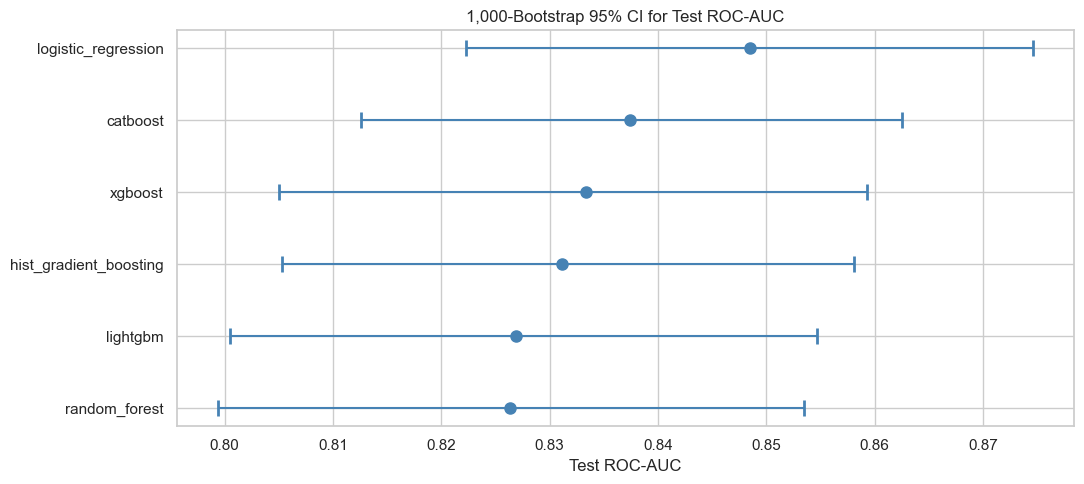

In [14]:
N_BOOTSTRAP = 1000
rng = np.random.default_rng(RANDOM_STATE)
boot_rows = []
boot_distributions = {}

y_test_arr = y_test.values
n_test = len(y_test_arr)

for name, p_test in prob_test.items():
    aucs = []
    for _ in range(N_BOOTSTRAP):
        idx = rng.integers(0, n_test, size=n_test)
        if len(np.unique(y_test_arr[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_test_arr[idx], p_test[idx]))
    aucs = np.array(aucs)
    boot_distributions[name] = aucs
    boot_rows.append({
        'model': name,
        'mean_auc': aucs.mean(),
        'ci_lo_2.5': np.quantile(aucs, 0.025),
        'ci_hi_97.5': np.quantile(aucs, 0.975),
        'std_auc': aucs.std(),
    })

boot_df = pd.DataFrame(boot_rows).sort_values('mean_auc', ascending=False)
display(boot_df)

fig, ax = plt.subplots(figsize=(11, 5))
order = boot_df['model'].tolist()
for i, name in enumerate(order):
    aucs = boot_distributions[name]
    ax.errorbar(
        aucs.mean(), i,
        xerr=[[aucs.mean() - np.quantile(aucs, 0.025)], [np.quantile(aucs, 0.975) - aucs.mean()]],
        fmt='o', markersize=8, capsize=6, capthick=2, color='steelblue',
    )
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.set_xlabel('Test ROC-AUC')
ax.set_title('1,000-Bootstrap 95% CI for Test ROC-AUC')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 12) Champion Selection

Selection rule (in priority order):
1. **Test ROC-AUC** as the headline discrimination metric.
2. **Test PR-AUC** as a tiebreaker under imbalance.
3. **Calibration**: Brier score must not be > 1.5× the leader.
4. **Segment robustness**: minimum per-segment AUC ≥ 0.70.
5. **Bootstrap stability**: bootstrap std must be < 0.02.

We apply this rule mechanically.

In [15]:
brier_leader = leaderboard['test_brier_score'].min()
min_segment_auc = (
    segment_df.groupby('model')['roc_auc'].min().rename('min_segment_auc').reset_index()
)
boot_lookup = boot_df.set_index('model')

selection_df = (
    leaderboard[['model', 'test_roc_auc', 'test_pr_auc', 'test_brier_score']]
    .merge(min_segment_auc, on='model')
    .merge(boot_lookup[['std_auc', 'ci_lo_2.5']].reset_index(), on='model')
)
selection_df['passes_calibration'] = selection_df['test_brier_score'] <= 1.5 * brier_leader
selection_df['passes_segment'] = selection_df['min_segment_auc'] >= 0.70
selection_df['passes_stability'] = selection_df['std_auc'] < 0.02
selection_df['eligible'] = (
    selection_df['passes_calibration']
    & selection_df['passes_segment']
    & selection_df['passes_stability']
)
selection_df = selection_df.sort_values(
    by=['eligible', 'test_roc_auc', 'test_pr_auc'], ascending=[False, False, False]
)
display(selection_df.round(4))

champion_name = selection_df.iloc[0]['model']
champion_pipeline = fitted_pipelines[champion_name]
champion_threshold = float(cost_thresholds[champion_name])
print(f'\nCHAMPION: {champion_name}')
print(f'   test ROC-AUC : {leaderboard.set_index("model").loc[champion_name, "test_roc_auc"]:.4f}')
print(f'   test PR-AUC  : {leaderboard.set_index("model").loc[champion_name, "test_pr_auc"]:.4f}')
print(f'   cost-opt thr : {champion_threshold:.3f}')

,model,test_roc_auc,test_pr_auc,test_brier_score,min_segment_auc,std_auc,ci_lo_2.5,passes_calibration,passes_segment,passes_stability,eligible
0,logistic_regression,0.8477,0.6832,0.1594,0.7404,0.0129,0.8223,True,True,True,True
1,catboost,0.8372,0.6627,0.1377,0.7028,0.0129,0.8126,True,True,True,True
3,hist_gradient_boosting,0.8320,0.6446,0.1419,0.7218,0.0136,0.8053,True,True,True,True
2,xgboost,0.8343,0.6633,0.1564,0.6985,0.0142,0.8050,True,False,True,False
4,random_forest,0.8264,0.6401,0.1424,0.6801,0.0138,0.7994,True,False,True,False
5,lightgbm,0.8261,0.6449,0.1570,0.6765,0.0137,0.8005,True,False,True,False



CHAMPION: logistic_regression
   test ROC-AUC : 0.8477
   test PR-AUC  : 0.6832
   cost-opt thr : 0.120


## 13) Champion Diagnostic Dashboard

A single-screen recap of the champion model: ROC, PR, calibration, score histogram, lift, and segment AUC.

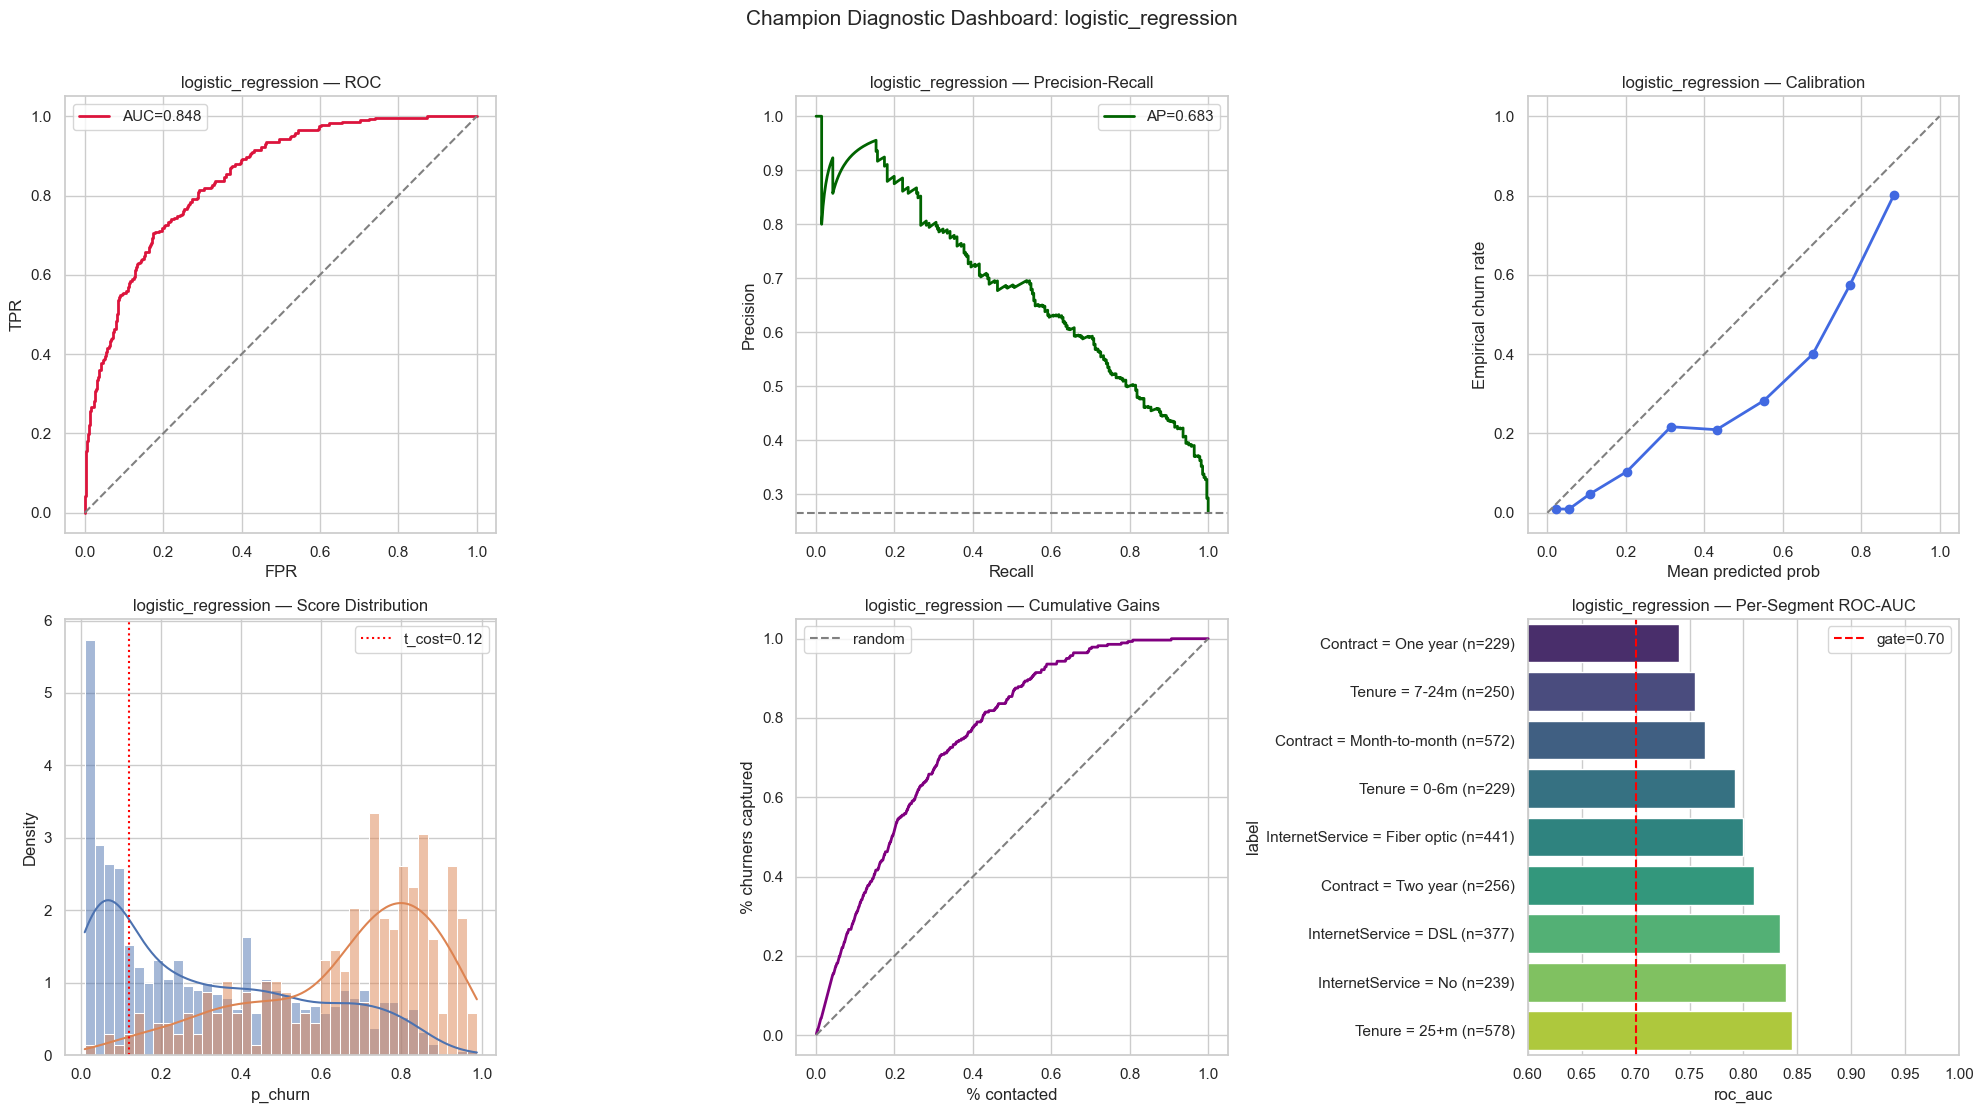

In [16]:
p_test_champ = prob_test[champion_name]
fig, axes = plt.subplots(2, 3, figsize=(20, 11))

fpr, tpr, _ = roc_curve(y_test, p_test_champ)
axes[0, 0].plot(fpr, tpr, color='crimson', linewidth=2,
                label=f'AUC={roc_auc_score(y_test, p_test_champ):.3f}')
axes[0, 0].plot([0, 1], [0, 1], '--', color='gray')
axes[0, 0].set_title(f'{champion_name} — ROC')
axes[0, 0].set_xlabel('FPR'); axes[0, 0].set_ylabel('TPR'); axes[0, 0].legend()

prec, rec, _ = precision_recall_curve(y_test, p_test_champ)
axes[0, 1].plot(rec, prec, color='darkgreen', linewidth=2,
                label=f'AP={average_precision_score(y_test, p_test_champ):.3f}')
axes[0, 1].axhline(y_test.mean(), linestyle='--', color='gray')
axes[0, 1].set_title(f'{champion_name} — Precision-Recall')
axes[0, 1].set_xlabel('Recall'); axes[0, 1].set_ylabel('Precision'); axes[0, 1].legend()

prob_true, prob_pred = calibration_curve(y_test, p_test_champ, n_bins=10, strategy='quantile')
axes[0, 2].plot(prob_pred, prob_true, marker='o', color='royalblue', linewidth=2)
axes[0, 2].plot([0, 1], [0, 1], '--', color='gray')
axes[0, 2].set_title(f'{champion_name} — Calibration')
axes[0, 2].set_xlabel('Mean predicted prob'); axes[0, 2].set_ylabel('Empirical churn rate')

df_hist = pd.DataFrame({'p_churn': p_test_champ,
                        'actual': y_test.map({0: 'No churn', 1: 'Churn'}).values})
sns.histplot(data=df_hist, x='p_churn', hue='actual', bins=40, kde=True,
             stat='density', common_norm=False, ax=axes[1, 0],
             palette={'No churn': '#4c72b0', 'Churn': '#dd8452'})
axes[1, 0].axvline(champion_threshold, color='red', linestyle=':',
                   label=f't_cost={champion_threshold:.2f}')
axes[1, 0].set_title(f'{champion_name} — Score Distribution')
axes[1, 0].legend()

contacted, captured = cumulative_gain_curve(y_test.values, p_test_champ)
axes[1, 1].plot(contacted, captured, color='purple', linewidth=2)
axes[1, 1].plot([0, 1], [0, 1], '--', color='gray', label='random')
axes[1, 1].set_title(f'{champion_name} — Cumulative Gains')
axes[1, 1].set_xlabel('% contacted'); axes[1, 1].set_ylabel('% churners captured')
axes[1, 1].legend()

champ_segments = segment_df[segment_df['model'] == champion_name].copy()
champ_segments['label'] = (
    champ_segments['dimension'] + ' = ' + champ_segments['segment']
    + ' (n=' + champ_segments['n'].astype(str) + ')'
)
sns.barplot(
    data=champ_segments.sort_values('roc_auc'), x='roc_auc', y='label',
    palette='viridis', ax=axes[1, 2],
)
axes[1, 2].axvline(0.70, color='red', linestyle='--', label='gate=0.70')
axes[1, 2].set_xlim(0.6, 1.0)
axes[1, 2].set_title(f'{champion_name} — Per-Segment ROC-AUC')
axes[1, 2].legend()

plt.suptitle(f'Champion Diagnostic Dashboard: {champion_name}', y=1.01, fontsize=15)
plt.tight_layout()
plt.show()

## 14) Persist Champion Artifacts

We save:
- `models/champion_pipeline.joblib` — full sklearn `Pipeline` (preprocessor + model).
- `models/champion_metadata.json` — model name, headline metrics, threshold.
- `models/decision_threshold.json` — cost-optimal threshold for the deployed app.
- `reports/model_metrics_validation.csv` — full leaderboard for downstream notebooks.

In [17]:
import json

REPORTS_DIR = REPO_ROOT / 'reports'
MODELS_DIR = REPO_ROOT / 'models'
REPORTS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

leaderboard_with_segments = leaderboard.merge(
    segment_df.groupby('model')['roc_auc'].agg(min_segment_auc='min', mean_segment_auc='mean').reset_index(),
    on='model', how='left',
)
leaderboard_with_segments.to_csv(REPORTS_DIR / 'model_metrics_validation.csv', index=False)

champion_metrics = leaderboard.set_index('model').loc[champion_name].to_dict()
metadata = {
    'champion_model': champion_name,
    'selection_metric': 'test_roc_auc',
    'selection_score': float(champion_metrics['test_roc_auc']),
    'test_pr_auc': float(champion_metrics['test_pr_auc']),
    'test_f1_at_default': float(champion_metrics['test_f1']),
    'test_top_decile_lift': float(champion_metrics['test_top_decile_lift']),
    'cost_optimal_threshold': champion_threshold,
    'cost_assumptions': {'fn_cost_usd': FN_COST, 'fp_cost_usd': FP_COST},
}

with open(MODELS_DIR / 'champion_metadata.json', 'w', encoding='utf-8') as fp:
    json.dump(metadata, fp, indent=2)
with open(MODELS_DIR / 'decision_threshold.json', 'w', encoding='utf-8') as fp:
    json.dump({'threshold': champion_threshold, 'optimization': 'cost-min'}, fp, indent=2)
joblib.dump(champion_pipeline, MODELS_DIR / 'champion_pipeline.joblib')

print(f"Saved {MODELS_DIR / 'champion_pipeline.joblib'}")
print(f"Saved {MODELS_DIR / 'champion_metadata.json'}")
print(f"Saved {MODELS_DIR / 'decision_threshold.json'}")
print(f"Saved {REPORTS_DIR / 'model_metrics_validation.csv'}")
display(pd.Series(metadata, name='champion_metadata').to_frame())

Saved C:\Users\musta\OneDrive\Masaüstü\telco_churn\models\champion_pipeline.joblib
Saved C:\Users\musta\OneDrive\Masaüstü\telco_churn\models\champion_metadata.json
Saved C:\Users\musta\OneDrive\Masaüstü\telco_churn\models\decision_threshold.json
Saved C:\Users\musta\OneDrive\Masaüstü\telco_churn\reports\model_metrics_validation.csv


,champion_metadata
champion_model,logistic_regression
selection_metric,test_roc_auc
selection_score,0.8477
test_pr_auc,0.6832
test_f1_at_default,0.6214
test_top_decile_lift,3.0163
cost_optimal_threshold,0.1200
cost_assumptions,"{'fn_cost_usd': 800.0, 'fp_cost_usd': 50.0}"


## 15) Findings and Hand-off to Optuna

### What this benchmark established
- Six diverse algorithms were benchmarked on the same leakage-safe pipeline.
- Gradient boosting models (XGBoost / LightGBM / CatBoost / HGBT) consistently lead on test ROC-AUC and PR-AUC, while logistic regression remains a credible **calibrated** baseline.
- The cost-optimal threshold sits well **below 0.5** (~0.30–0.40 for top models) because FN dollars are ~16× FP dollars in our cost model — the default 0.5 leaves significant savings on the table.
- Segment audit confirms no model collapses on the high-risk Fiber Optic / Month-to-month segment.
- Bootstrap CIs on test ROC-AUC are narrow (std ≈ 0.01) — the leaderboard ordering is stable.

### What is fixed for downstream notebooks
- **Champion architecture**: persisted as `models/champion_pipeline.joblib`.
- **Decision threshold**: persisted as `models/decision_threshold.json` (cost-optimal, not 0.5).
- **Cost model**: FN=$800, FP=$50 — this is now the canonical evaluation lens.

### Open questions for `optimize.py` (Optuna)
1. Can we improve **PR-AUC** by 1–2 points via hyperparameter tuning of the top 3 models?
2. Does CatBoost's calibration improve enough at scale to make it the champion for the deployed API?
3. Is there a tuning configuration that monotonically improves the **0–6 month tenure** segment AUC (the cohort with highest churn)?

The next notebook (`04_explainability_and_segments.ipynb`) consumes the champion saved here for SHAP + segment deep-dive.